正在讀取資料...
計算衍生變數 (ROA, LEV, SIZE, ICR)...
定義特徵數: 21, 實際存在: 13
繪製 Missing Map (全量數據)...


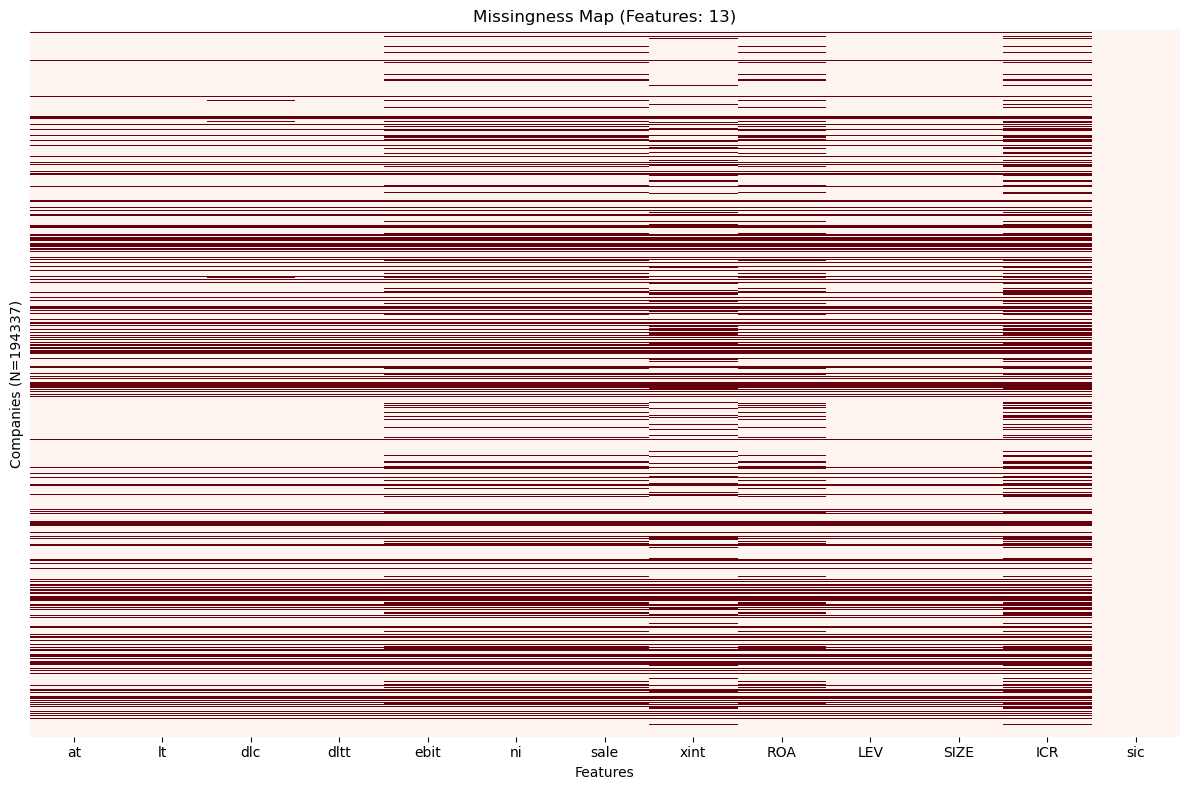

執行填補策略: SIC2 x Year Median (Train-only)...
執行 Winsorization (1%-99%)...

[PPT Page 8: Descriptive Statistics]


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
at,194337.0,1.578484e+04,1.316196e+05,0.000000e+00,143.71,782.56,3041.05,4.349731e+06,16.678971,335.208365
lt,194337.0,1.336429e+04,1.233880e+05,-1.000000e-01,50.37,421.99,1643.54,4.255074e+06,17.31502,360.76681
dlc,194337.0,1.060380e+03,1.340219e+04,-5.600000e+01,0.40,7.81,36.15,6.142374e+05,22.555344,611.534495
dltt,194337.0,3.011600e+03,5.403429e+04,-2.000000e-02,2.00,58.80,975.81,4.216909e+06,57.624915,3679.057504
ebit,194337.0,3.541800e+02,2.645240e+03,-2.838700e+04,-0.39,3.97,72.52,1.412900e+05,22.554573,760.769294
ni,194337.0,1.808600e+02,1.596600e+03,-2.311900e+04,-1.61,0.05,32.83,1.018320e+05,25.600388,1139.399357
sale,194337.0,2.484210e+03,1.455411e+04,-2.495468e+04,44.03,166.73,430.53,6.809850e+05,17.071496,430.195981
xint,194337.0,1.464000e+02,1.910340e+03,-3.775000e+03,1.09,6.60,49.35,1.378610e+05,39.401923,1913.114663
ROA,194337.0,-4.476257e+06,4.944373e+08,-1.154960e+11,-0.04,0.00,0.02,1.350200e+10,-174.640499,35830.490996
LEV,194337.0,8.467933e+05,5.532495e+07,0.000000e+00,0.06,0.19,0.46,1.172300e+10,131.788499,22240.487049


繪製 Correlation Heatmap (Model Features)...


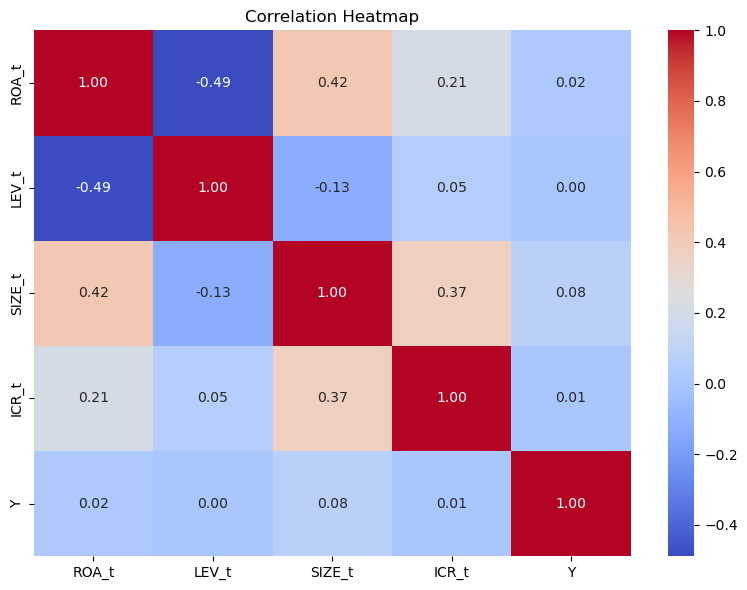


繪製 Pairplot (Sampled)...


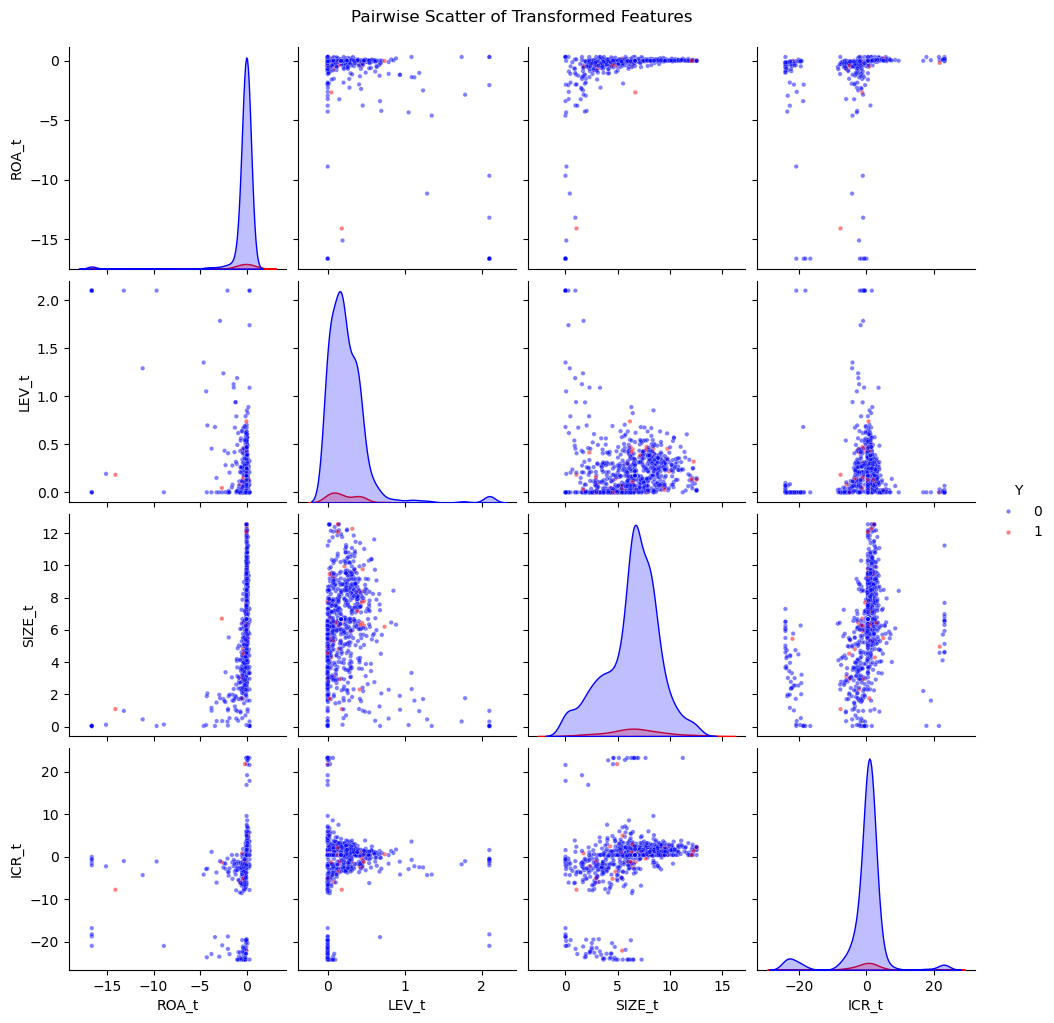


準備模型數據並存檔...
EDA 完成。模型輸入特徵數: 4 ['ROA_t', 'LEV_t', 'SIZE_t', 'ICR_t']


In [11]:
# 1_EDA_data_prep.ipynb
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import joblib

# --- 設定路徑 ---
BASE_DIR = r"C:\Users\User-NB\OneDrive\Desktop\ML"
RAW_CSV = os.path.join(BASE_DIR, "Fundamentals Annual_withY.csv")
OUTPUT_DIR = os.path.join(BASE_DIR, "processed_data")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. 讀取資料
print("正在讀取資料...")
df = pd.read_csv(RAW_CSV)
# 確保 Y 存在 (雙重保險)
if 'y' in df.columns: df.rename(columns={'y': 'Y'}, inplace=True)

# 2. 定義特徵 & 計算衍生變數
# 這是給 EDA 畫圖用的 "Raw Features" (符合 PPT Page 4 & 5)
raw_features_21 = [
    "at", "lt", "dlc", "dltt", "ebit", "ni", "sale", "xint", 
    "che", "invt", "rect", "ap", "txt", "re", "cogs", "xopr",
    "ROA", "LEV", "SIZE", "ICR", "sic" 
]

print("計算衍生變數 (ROA, LEV, SIZE, ICR)...")
eps = 1e-9
# 確保分母不為 0
df["ROA"]  = df["ni"] / (df["at"] + eps)
df["LEV"]  = (df["dlc"].fillna(0) + df["dltt"].fillna(0)) / (df["at"] + eps)
df["SIZE"] = np.log(df["at"] + 1.0)
df["ICR"]  = df["ebit"] / (df["xint"] + eps)

# ★★★ 修正點 1: 過濾實際存在的欄位，避免 KeyError ★★★
existing_raw_features = [c for c in raw_features_21 if c in df.columns]
print(f"定義特徵數: {len(raw_features_21)}, 實際存在: {len(existing_raw_features)}")

# 3. 畫 Missing Map (PPT Page 5)
print("繪製 Missing Map (全量數據)...")
plt.figure(figsize=(12, 8))
sns.heatmap(df[existing_raw_features].isnull(), cbar=False, cmap="Reds", yticklabels=False)
plt.title(f"Missingness Map (Features: {len(existing_raw_features)})")
plt.xlabel("Features")
plt.ylabel(f"Companies (N={len(df)})")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_missing_map.png"))
plt.show()

# 4. 數據前處理 (Preprocessing)
work = df.copy()

# --- (A) 填補缺失值 (Imputation) ---
print("執行填補策略: SIC2 x Year Median (Train-only)...")

# 建立輔助欄位：SIC2 (產業前兩碼)
work['sic'] = work['sic'].fillna(0).astype(int).astype(str).str.zfill(4)
work['SIC2'] = work['sic'].str[:2]

# 定義訓練集範圍 (2019-2023) 用於計算統計量，避免 Data Leakage
train_mask = (work['fyear'] >= 2019) & (work['fyear'] <= 2023)

for col in existing_raw_features:
    if col in ['Y', 'fyear', 'gvkey', 'sic', 'SIC2']: continue
    if work[col].isnull().sum() == 0: continue # 沒缺值就跳過

    # 1. 計算分組中位數 (只用 Train Set)
    group_medians = work[train_mask].groupby(['SIC2', 'fyear'])[col].median()
    # 2. 計算全域中位數 (備案)
    global_median = work.loc[train_mask, col].median()
    
    # 3. 映射填補
    # 將每個樣本對應的 SIC2+fyear 的中位數找出來
    mapped_medians = work.set_index(['SIC2', 'fyear']).index.map(group_medians)
    
    # 優先用分組中位數填，填不到的用全域中位數
    work[col] = work[col].fillna(pd.Series(mapped_medians, index=work.index)).fillna(global_median)

# --- (B) 轉換與縮尾 (Winsorization & Log) ---
# 針對模型要用的 4 個關鍵變數 
model_features = ["ROA_t", "LEV_t", "SIZE_t", "ICR_t"]

def sign_log1p(x): return np.sign(x) * np.log1p(np.abs(x))

# 確保基礎欄位已填補
work["LEV_t"] = np.log1p(work["LEV"].clip(lower=0))
work["ICR_t"] = sign_log1p(work["ICR"])
work["ROA_t"] = work["ROA"]
work["SIZE_t"] = work["SIZE"]

# Winsorize 1%-99%
print("執行 Winsorization (1%-99%)...")
for c in model_features:
    lo, hi = work[c].quantile([0.01, 0.99])
    work[c] = work[c].clip(lo, hi)

# 5. 生成敘述性統計表 (PPT Page 8)
# ★★★ 修正點 3: 使用 filtered columns 避免 crash ★★★
print("\n[PPT Page 8: Descriptive Statistics]")
# 這裡計算的是原始變數(經過補值後)的統計量
desc_stats = work[existing_raw_features].describe().T
desc_stats['skewness'] = work[existing_raw_features].skew()
desc_stats['kurtosis'] = work[existing_raw_features].kurtosis()

cols_to_show = ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skewness', 'kurtosis']
# 顯示並存檔
display(desc_stats[cols_to_show].round(2))
desc_stats[cols_to_show].to_csv(os.path.join(OUTPUT_DIR, "eda_descriptive_stats.csv"))

# 6. 相關性熱圖 (PPT Page 9)
# 這裡畫「轉換後」的模型變數相關性，檢查共線性
print("繪製 Correlation Heatmap (Model Features)...")
plt.figure(figsize=(8, 6))
# 為了對應 PPT，我們也畫一些 size 相關的變數
corr_cols = model_features + ['Y']
sns.heatmap(work[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_correlation.png"))
plt.show()

# 7. 繪製 Pairplot (PPT Page 9)
print("\n繪製 Pairplot (Sampled)...")
# 隨機抽樣 1000 點來畫圖，避免跑太久
sample_df = work.sample(n=1000, random_state=42)
pair_cols = model_features + ['Y']

sns.pairplot(sample_df[pair_cols], hue='Y', diag_kind='kde', 
             plot_kws={'alpha': 0.5, 's': 10}, palette={0: 'blue', 1: 'red'})
plt.suptitle("Pairwise Scatter of Transformed Features", y=1.02)
plt.savefig(os.path.join(OUTPUT_DIR, "eda_pairplot.png"))
plt.show()

# 8. 輸出模型數據
print("\n準備模型數據並存檔...")
scaler = StandardScaler()
X = scaler.fit_transform(work[model_features].values)
y = work["Y"].values
fyear = work["fyear"].fillna(0).astype(int).values

data_packet = {
    "X": X, "y": y, "fyear": fyear,
    "feature_names": model_features,
    "scaler": scaler
}
joblib.dump(data_packet, os.path.join(OUTPUT_DIR, "data_processed.pkl"))
print(f"EDA 完成。模型輸入特徵數: {X.shape[1]} {model_features}")